# 🎓 Recap 2025 — Lớp Mình
### *Một năm nhìn lại qua dữ liệu* 📊

> Notebook visualize kết quả khảo sát năm 2025 của lớp: sức khoẻ, tinh thần, thói quen, tình cảm.

**Nội dung:**
1. Overview — Big numbers
2. Công việc & Học hành
3. Sức khoẻ
4. Tinh thần
5. Thói quen
6. Đời sống tình cảm
7. Phân tích chéo
8. Fun Facts

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter
import warnings; warnings.filterwarnings('ignore')

COLORS = {
    'bg':    '#f2e7d3', 'panel': '#fdf6ec',
    'a1':    '#0264f4', 'a2':    '#a27e51',
    'a3':    '#c94a2b', 'a4':    '#1a4db8',
    'a5':    '#3d7a4e', 'a6':    '#7a5c3a',
    'text':  '#000000', 'muted': '#5a4a38',
}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor':   COLORS['panel'],
    'axes.edgecolor':   '#2e2d3d',
    'text.color':       COLORS['text'],
    'axes.labelcolor':  COLORS['text'],
    'xtick.color':      COLORS['muted'],
    'ytick.color':      COLORS['muted'],
    'grid.color':       '#2e2d3d',
    'grid.linewidth':   0.5,
    'font.size':        11,
})

df = pd.read_csv('recap2025.csv')

COL_WORK   = 'Công việc, học hành'
COL_HEALTH = 'Năm qua sức khỏe bạn thế nào?'
COL_MENTAL = 'Năm qua tinh thần bạn ra sao?'
COL_HABITS = 'Năm qua, bạn có những thói quen gì?'
COL_LOVE   = 'Đời sống tình cảm'

def explode_col(col):
    items = []
    for val in df[col].dropna():
        items.extend([x.strip() for x in str(val).split(';') if x.strip()])
    return Counter(items)

def has_kw(val, kw):
    return False if pd.isna(val) else kw.lower() in str(val).lower()

print(f'Loaded {len(df)} responses!')
df.head(3)

Loaded 39 responses!


,Timestamp,Tên của cậu là gì?,"Công việc, học hành",Năm qua sức khỏe bạn thế nào?,Năm qua tinh thần bạn ra sao?,"Năm qua, bạn có những thói quen gì?",Đời sống tình cảm
0,2026/02/10 8:33:32 PM GMT+7,Nguyễn Hải,Tham gia 1 cuộc thi,Thoát vị đĩa đệm,Cười ặc ặc;Một năm chill guy;Vô tư về tương la...,Thích ở nhà hơn là ra ngoài đông người;Không c...,Đang hẹn hò (có danh phận rõ ràng)
1,2026/02/10 8:37:53 PM GMT+7,Vân Anh,Làm cán sự lớp;Cúp học;Đi thực tập;Đi làm full...,Thiếu ngủ trầm trọng;Hay ốm vặt;Vào viện ít nh...,Có những lúc stress phát điên;Lo lắng cho tươn...,Thích ở nhà hơn là ra ngoài đông người;Chọn ch...,Có mối quan hệ mập mờ (khó gọi tên nhưng vẫn t...
2,2026/02/10 8:42:27 PM GMT+7,Hồng Huệ,Học thêm 1 kỹ năng/ngôn ngữ mới;Đi thực tập;Gi...,Hay ốm vặt;Tăng độ cận;Tăng cân;Ăn uống healthy,Có những lúc stress phát điên;Có nhiều điều th...,Chọn chất lượng hơn số lượng trong các mối qua...,Độc thân hoàn toàn (chưa yêu đương với ai)


## 📌 Overview — Những con số nổi bật

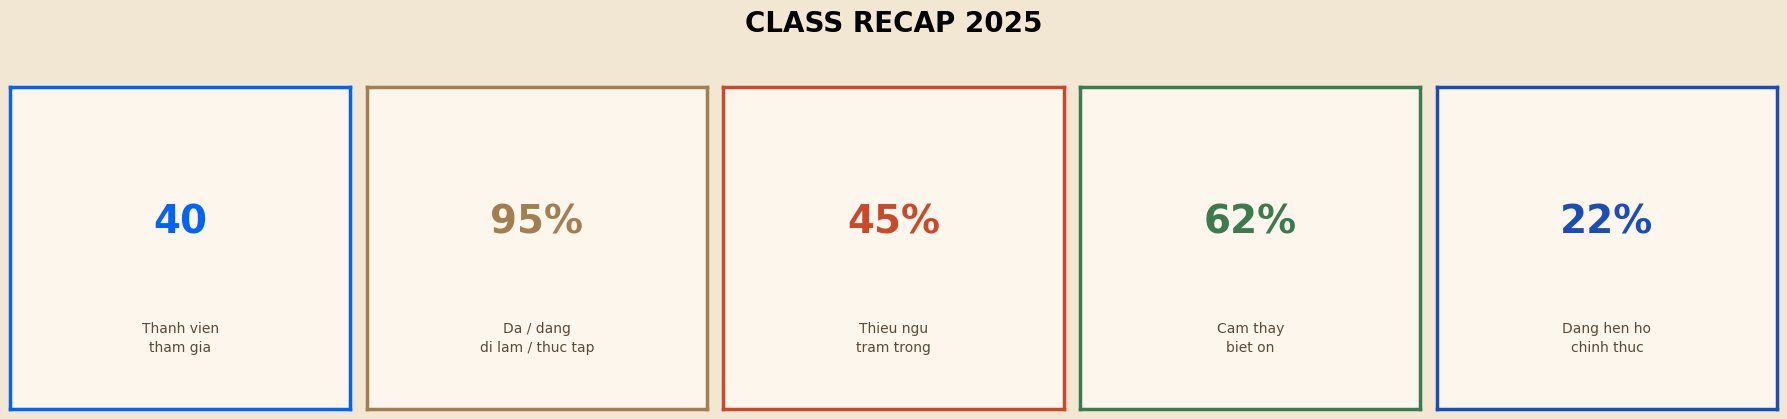

In [38]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('CLASS RECAP 2025', fontsize=20, fontweight='bold',
             color=COLORS['text'], y=1.04)

stats = [
    ('40',    'Thanh vien\ntham gia',          COLORS['a1']),
    ('95%',   'Da / dang\ndi lam / thuc tap',  COLORS['a2']),
    ('45%',   'Thieu ngu\ntram trong',          COLORS['a3']),
    ('62%',   'Cam thay\nbiet on',              COLORS['a5']),
    ('22%',   'Dang hen ho\nchinh thuc',        COLORS['a4']),
]

for ax, (num, label, color) in zip(axes, stats):
    ax.set_facecolor(COLORS['panel'])
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.58, num, ha='center', va='center',
            transform=ax.transAxes, fontsize=28, fontweight='bold', color=color)
    ax.text(0.5, 0.22, label, ha='center', va='center',
            transform=ax.transAxes, fontsize=10,
            color=COLORS['muted'], linespacing=1.5)

plt.tight_layout()
plt.savefig('chart_overview.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

## 💼 Công việc & Học hành — Lớp mình đã làm gì năm qua?

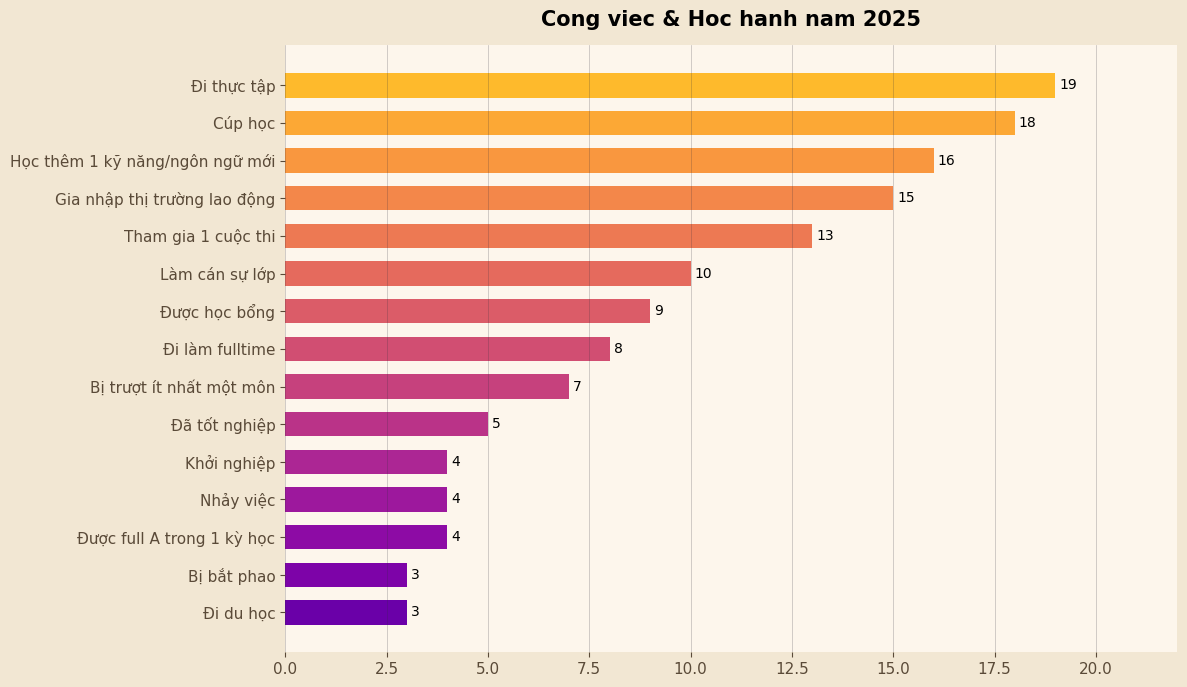

In [39]:
wc = explode_col(COL_WORK)
lmap = {
    'Hoc them 1 ky nang/ngon ngu moi': 'Hoc ky nang moi',
    'Gia nhap thi truong lao dong': 'Gia nhap TT lao dong',
    'Duoc full A trong 1 ky hoc': 'Full A mot ky',
    'Bi truot it nhat mot mon': 'Truot >=1 mon',
    'Tham gia 1 cuoc thi': 'Tham gia cuoc thi',
    'Lam can su lop': 'Can su lop',
    'Da tot nghiep': 'Tot nghiep',
    'Di lam fulltime': 'Di lam fulltime',
    'Di thuc tap': 'Di thuc tap',
    'Duoc hoc bong': 'Hoc bong',
    'Di du hoc': 'Du hoc',
    'Nhay viec': 'Nhay viec',
    'Khoi nghiep': 'Khoi nghiep',
    'Bi bat phao': 'Bi bat phao',
    'Cup hoc': 'Cup hoc',
}

sorted_w = sorted(wc.items(), key=lambda x: x[1])
labels_w = [k for k, v in sorted_w]
values_w = [v for k, v in sorted_w]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])
colors_grad = plt.cm.plasma(np.linspace(0.2, 0.85, len(values_w)))
bars = ax.barh(labels_w, values_w, color=colors_grad, height=0.65, edgecolor='none')
for bar, val in zip(bars, values_w):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, color=COLORS['text'])
ax.set_title('Cong viec & Hoc hanh nam 2025',
             fontsize=15, fontweight='bold', color=COLORS['text'], pad=14)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(values_w) + 3)
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout()
plt.savefig('chart_work.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

## 💊 Sức khoẻ — Cơ thể nói gì năm qua?

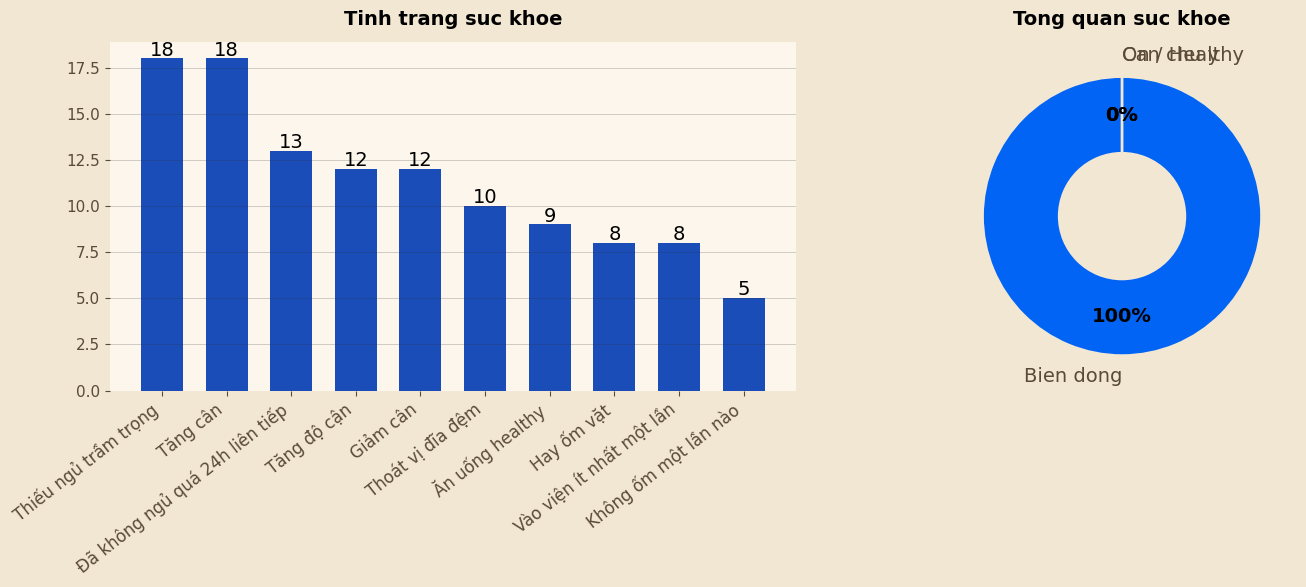

In [40]:
hc = explode_col(COL_HEALTH)

lmap_h = {
    'Thieu ngu tram trong': 'Thieu ngu tram trong',
    'Tang can': 'Tang can',
    'Da khong ngu qua 24h lien tiep': 'Thuc > 24h lien tiep',
    'Tang do can': 'Tang do can',
    'Giam can': 'Giam can',
    'Hay om vat': 'Hay om vat',
    'Vao vien it nhat mot lan': 'Vao vien >=1 lan',
    'Thoat vi dia dem': 'Thoat vi dia dem',
    'An uong healthy': 'An uong healthy',
    'Khong om mot lan nao': 'Khong om lan nao',
}

sorted_h = sorted(hc.items(), key=lambda x: x[1], reverse=True)
labels_h = [k for k, v in sorted_h]
values_h = [v for k, v in sorted_h]

bad_k  = {'Thieu ngu tram trong', 'Hay om vat', 'Vao vien it nhat mot lan',
          'Thoat vi dia dem', 'Da khong ngu qua 24h lien tiep'}
good_k = {'An uong healthy', 'Khong om mot lan nao'}

bcolors = [COLORS['a3'] if k in bad_k else
           COLORS['a5'] if k in good_k else
           COLORS['a4'] for k in labels_h]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(COLORS['bg'])

ax1.set_facecolor(COLORS['panel'])
bars = ax1.bar(range(len(labels_h)), values_h, color=bcolors,
               width=0.65, edgecolor='none')
ax1.set_xticks(range(len(labels_h)))
ax1.set_xticklabels(labels_h, rotation=38, ha='right', fontsize=12)
ax1.set_title('Tinh trang suc khoe',
              fontsize=14, fontweight='bold', color=COLORS['text'], pad=12)
for bar, val in zip(bars, values_h):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             str(val), ha='center', fontsize=14, color=COLORS['text'])
ax1.grid(axis='y', alpha=0.3)
for spine in ax1.spines.values(): spine.set_visible(False)

# Donut chart
bad_n  = sum(hc.get(k, 0) for k in bad_k)
good_n = sum(hc.get(k, 0) for k in good_k)
neutral_n = sum(v for k, v in hc.items() if k not in bad_k and k not in good_k)
ax2.set_facecolor(COLORS['panel'])
pie_d = [bad_n, neutral_n, good_n]
pie_l = ['Can chu y', 'Bien dong', 'On / Healthy']
pie_c = [COLORS['a3'], COLORS['a1'], COLORS['a5']]
wedges, texts, autotexts = ax2.pie(
    pie_d, labels=pie_l, autopct='%1.0f%%', colors=pie_c, startangle=90,
    pctdistance=0.72, labeldistance=1.15,
    wedgeprops=dict(width=0.55, edgecolor=COLORS['bg'], linewidth=2))
for t in texts:     t.set_color(COLORS['muted']); t.set_fontsize(14)
for at in autotexts: at.set_color(COLORS['text']); at.set_fontsize(14); at.set_fontweight('bold')
ax2.set_title('Tong quan suc khoe',
              fontsize=14, fontweight='bold', color=COLORS['text'], pad=12)
plt.tight_layout()
plt.savefig('chart_health.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

## 🧠 Tinh thần — Cảm xúc cả năm của lớp

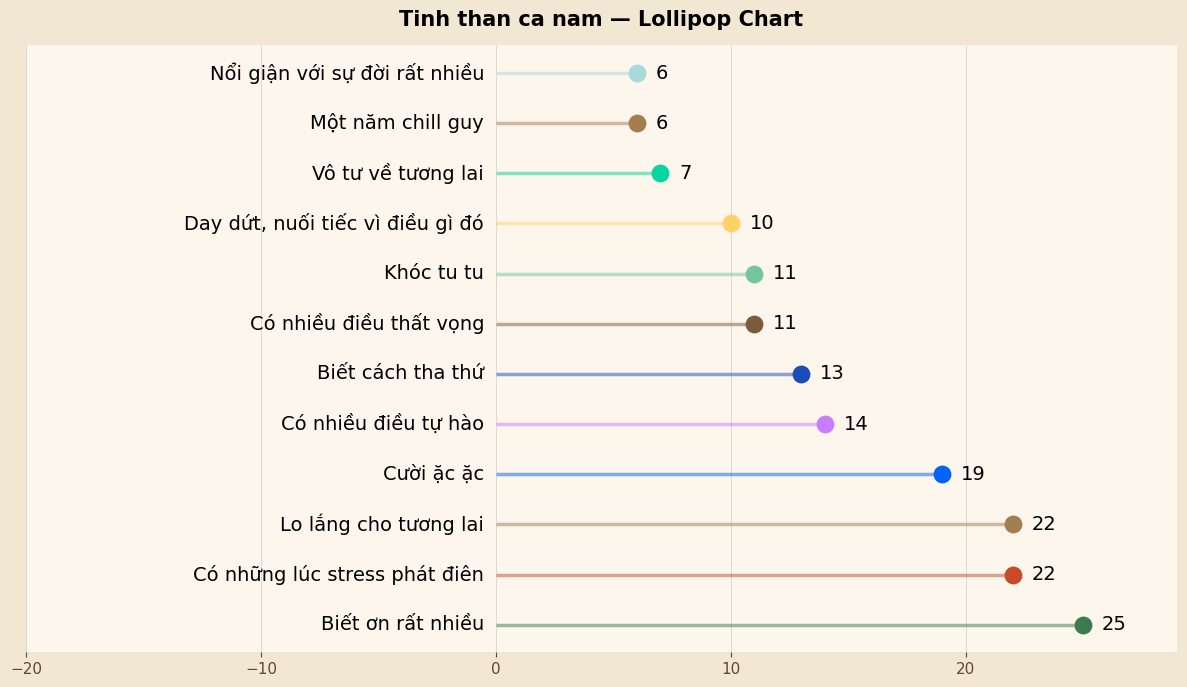

In [41]:
mc = explode_col(COL_MENTAL)

sorted_m = sorted(mc.items(), key=lambda x: x[1], reverse=True)
labels_m = [k for k, v in sorted_m]
values_m = [v for k, v in sorted_m]

emotion_colors = [COLORS['a5'], COLORS['a3'], COLORS['a2'], COLORS['a1'],
                  '#c77dff', COLORS['a4'], COLORS['a6'], '#74c69d',
                  '#ffd166', '#06d6a0', COLORS['a2'], '#a8dadc']
emotion_colors = emotion_colors[:len(values_m)]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])

for i, (val, color, label) in enumerate(zip(values_m, emotion_colors, labels_m)):
    ax.hlines(i, 0, val, color=color, linewidth=2.5, alpha=0.5)
    ax.scatter(val, i, color=color, s=140, zorder=5)
    ax.text(val + 0.8, i, str(val), va='center', fontsize=14, color=COLORS['text'])
    ax.text(-0.5, i, label, va='center', ha='right', fontsize=14, color=COLORS['text'])

ax.set_yticks([])
ax.set_xlim(-20, max(values_m) + 4)
ax.set_title('Tinh than ca nam — Lollipop Chart',
             fontsize=15, fontweight='bold', color=COLORS['text'], pad=14)
ax.grid(axis='x', alpha=0.2)
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout()
plt.savefig('chart_mental.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

## 📱 Thói quen — Lớp mình sống thế nào?

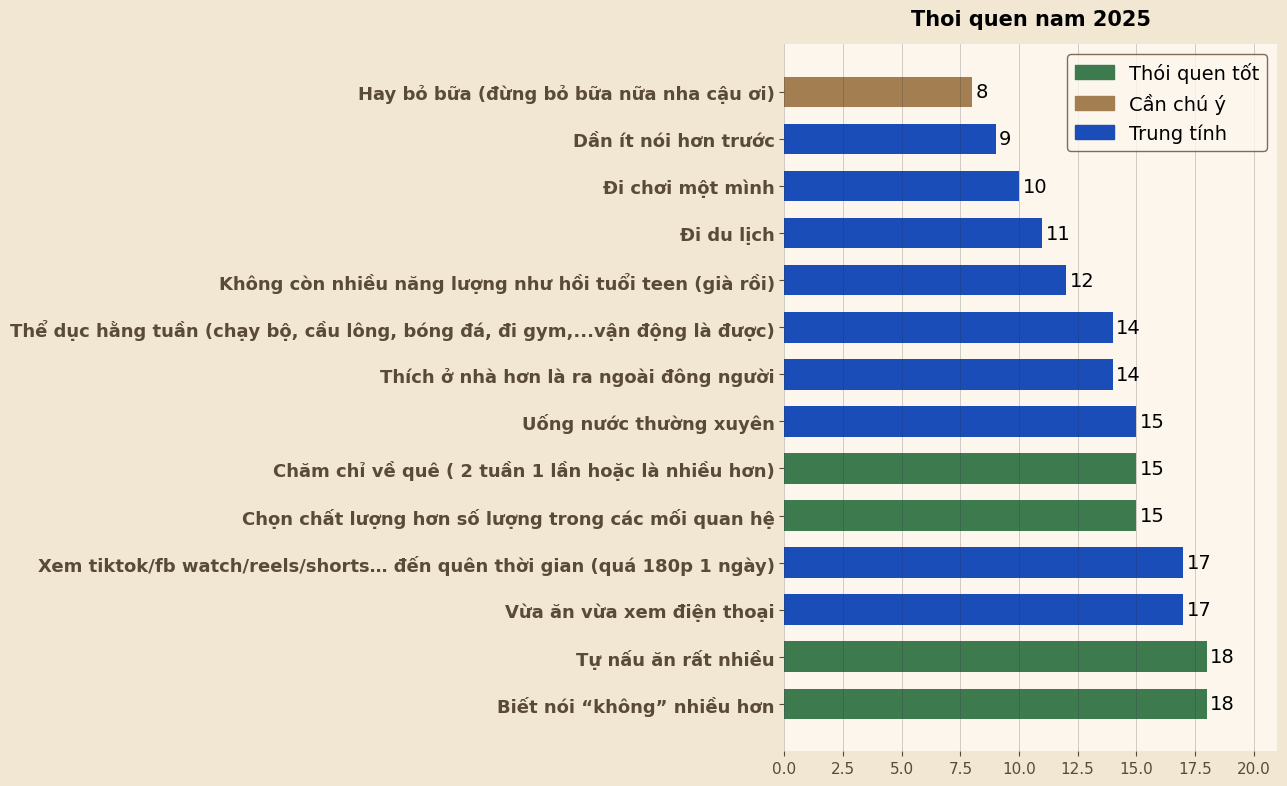

In [42]:
hab = explode_col(COL_HABITS)

pos_kw = ['Biet noi khong', 'The duc', 'Uong nuoc', 'Du lich', 'Cham ve que',
           'nau an', 'chat luong']
neg_kw = ['vua an vua', 'tiktok', 'bo bua', 'ngu bu', 'an ngoai']

def classify(k):
    kl = k.lower()
    if any(p in kl for p in ['biết nói', 'Thể dục', 'Uống nước', 'du lich', 'về quê', 'nấu ăn', 'chất lượng', 'nhiều hơn']): return 'pos'
    if any(n in kl for n in ['Vừa ăn', 'Tiktok', 'bỏ bữa', 'ngủ bù', 'Ăn ngoài']): return 'neg'
    return 'neu'

sorted_hab = sorted(hab.items(), key=lambda x: x[1], reverse=True)[:14]
labels_hab = [k for k, v in sorted_hab]
values_hab = [v for k, v in sorted_hab]
bcolors_hab = [COLORS['a5'] if classify(k) == 'pos' else
               COLORS['a2'] if classify(k) == 'neg' else
               COLORS['a4'] for k in labels_hab]

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])
bars = ax.barh(range(len(labels_hab)), values_hab,
               color=bcolors_hab, height=0.65, edgecolor='none')
ax.set_yticks(range(len(labels_hab)))
ax.set_yticklabels(labels_hab, fontsize=13, fontweight='bold')
for bar, val in zip(bars, values_hab):
    ax.text(val + 0.15, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=14, color=COLORS['text'])
legend_patches = [
    mpatches.Patch(color=COLORS['a5'], label='Thói quen tốt'),
    mpatches.Patch(color=COLORS['a2'], label='Cần chú ý'),
    mpatches.Patch(color=COLORS['a4'], label='Trung tính'),
]
ax.legend(handles=legend_patches, loc='upper right',
          facecolor=COLORS['panel'], edgecolor=COLORS['muted'],
          labelcolor=COLORS['text'], fontsize=14)
ax.set_title('Thoi quen nam 2025',
             fontsize=15, fontweight='bold', color=COLORS['text'], pad=14)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(values_hab) + 3)
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout()
plt.savefig('chart_habits.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

## 💕 Đời sống tình cảm — Ai đang ở đâu?

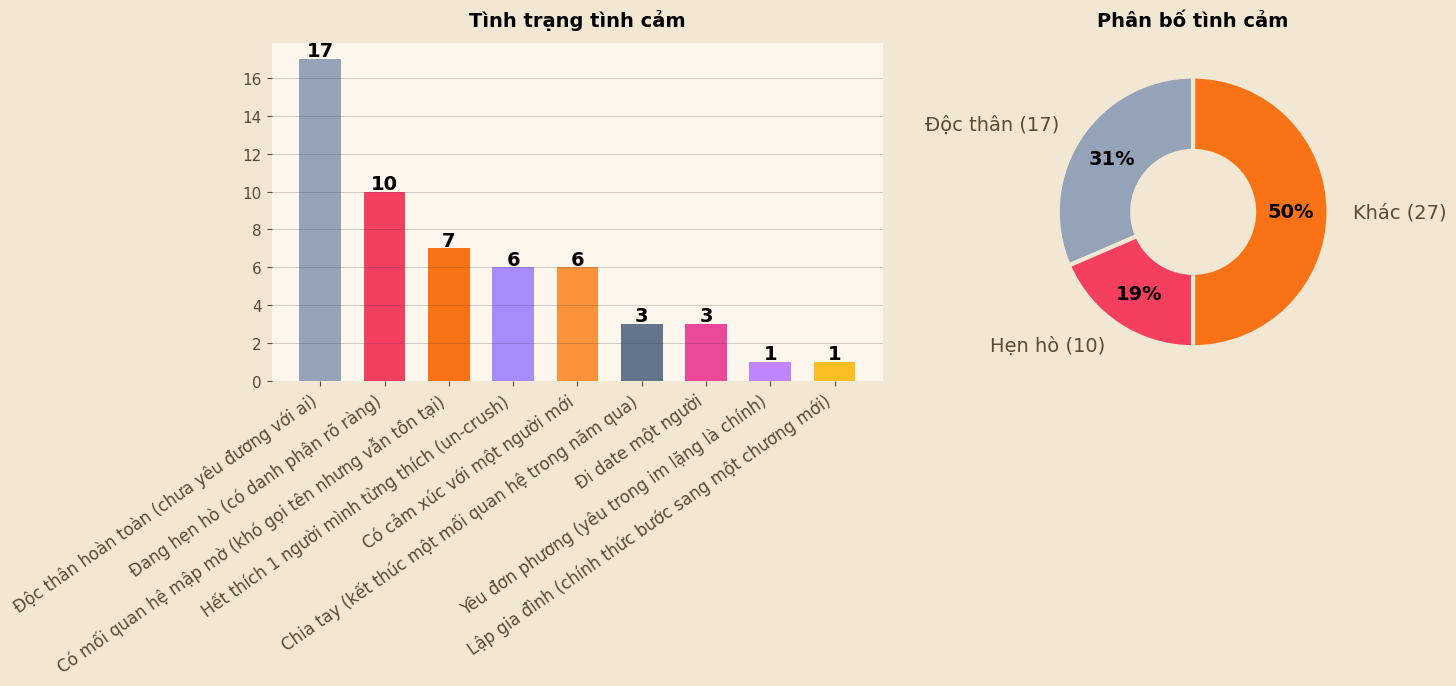

In [43]:
lc = explode_col(COL_LOVE)

sorted_l = sorted(lc.items(), key=lambda x: x[1], reverse=True)
labels_l = [k for k, v in sorted_l]
values_l = [v for k, v in sorted_l]
love_clrs = ['#94a3b8','#f43f5e','#f97316','#a78bfa',
             '#fb923c','#64748b','#ec4899','#c084fc','#fbbf24'][:len(values_l)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7),
                                gridspec_kw={'width_ratios': [1.5, 1]})
fig.patch.set_facecolor(COLORS['bg'])

ax1.set_facecolor(COLORS['panel'])
bars = ax1.bar(range(len(labels_l)), values_l,
               color=love_clrs, width=0.65, edgecolor='none')
ax1.set_xticks(range(len(labels_l)))
ax1.set_xticklabels(labels_l, rotation=35, ha='right', fontsize=12)
for bar, val in zip(bars, values_l):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             str(val), ha='center', fontsize=14, fontweight='bold', color=COLORS['text'])
ax1.set_title('Tình trạng tình cảm',
              fontsize=14, fontweight='bold', color=COLORS['text'], pad=12)
ax1.grid(axis='y', alpha=0.3)
for spine in ax1.spines.values(): spine.set_visible(False)

# Donut
doc_than_key = [k for k in lc if 'doc than' in k.lower() or 'độc thân' in k.lower()]
hen_ho_key   = [k for k in lc if 'hen ho' in k.lower() or 'hẹn hò' in k.lower()]
single = sum(lc[k] for k in doc_than_key)
dating = sum(lc[k] for k in hen_ho_key)
other  = sum(values_l) - single - dating
ax2.set_facecolor(COLORS['panel'])
pie_d = [single, dating, other]
pie_l2 = [f'Độc thân ({single})', f'Hẹn hò ({dating})', f'Khác ({other})']
pie_c2 = ['#94a3b8', '#f43f5e', '#f97316']
wedges, texts, autotexts = ax2.pie(
    pie_d, labels=pie_l2, autopct='%1.0f%%', colors=pie_c2, startangle=90,
    pctdistance=0.72, labeldistance=1.18,
    wedgeprops=dict(width=0.55, edgecolor=COLORS['bg'], linewidth=3))
for t in texts:     t.set_color(COLORS['muted']); t.set_fontsize(14)
for at in autotexts: at.set_color(COLORS['text']); at.set_fontsize(14); at.set_fontweight('bold')
ax2.set_title('Phân bố tình cảm',
              fontsize=14, fontweight='bold', color=COLORS['text'], pad=12)
plt.tight_layout()
plt.savefig('chart_love.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

## 🔍 Phân tích chéo — Đi làm fulltime vs. Chưa

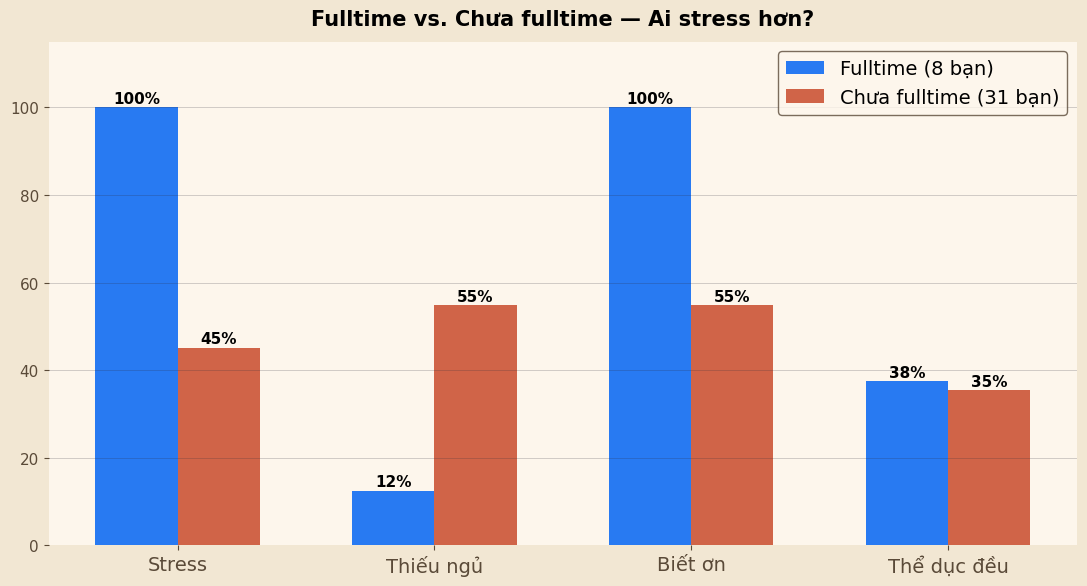

In [44]:
fulltime_kw = 'fulltime'
df['is_working']       = df[COL_WORK].apply(lambda x: has_kw(x, fulltime_kw))
df['is_stressed']      = df[COL_MENTAL].apply(lambda x: has_kw(x, 'stress'))
df['is_sleep_dep']     = df[COL_HEALTH].apply(lambda x: has_kw(x, 'thieu ngu') or has_kw(x, 'thiếu ngủ'))
df['is_grateful']      = df[COL_MENTAL].apply(lambda x: has_kw(x, 'biet on') or has_kw(x, 'biết ơn'))
df['exercises']        = df[COL_HABITS].apply(lambda x: has_kw(x, 'Thể dục'))

w = df[df['is_working']]
s = df[~df['is_working']]

cats = ['Stress', 'Thiếu ngủ', 'Biết ơn', 'Thể dục đều']
w_v = [w['is_stressed'].mean()*100, w['is_sleep_dep'].mean()*100,
       w['is_grateful'].mean()*100, w['exercises'].mean()*100]
s_v = [s['is_stressed'].mean()*100, s['is_sleep_dep'].mean()*100,
       s['is_grateful'].mean()*100, s['exercises'].mean()*100]

x = np.arange(len(cats)); bw = 0.32
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])
b1 = ax.bar(x - bw/2, w_v, bw, label=f'Fulltime ({len(w)} bạn)',
            color=COLORS['a1'], alpha=0.85, edgecolor='none')
b2 = ax.bar(x + bw/2, s_v, bw, label=f'Chưa fulltime ({len(s)} bạn)',
            color=COLORS['a3'], alpha=0.85, edgecolor='none')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.0f}%', ha='center',
                fontsize=11, fontweight='bold', color=COLORS['text'])
ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=14)
ax.set_title('Fulltime vs. Chưa fulltime — Ai stress hơn?',
             fontsize=15, fontweight='bold', color=COLORS['text'], pad=12)
ax.legend(facecolor=COLORS['panel'], edgecolor=COLORS['muted'],
          labelcolor=COLORS['text'], fontsize=14)
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout()
plt.savefig('chart_crossanalysis.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

## 🎲 Fun Facts từ Data

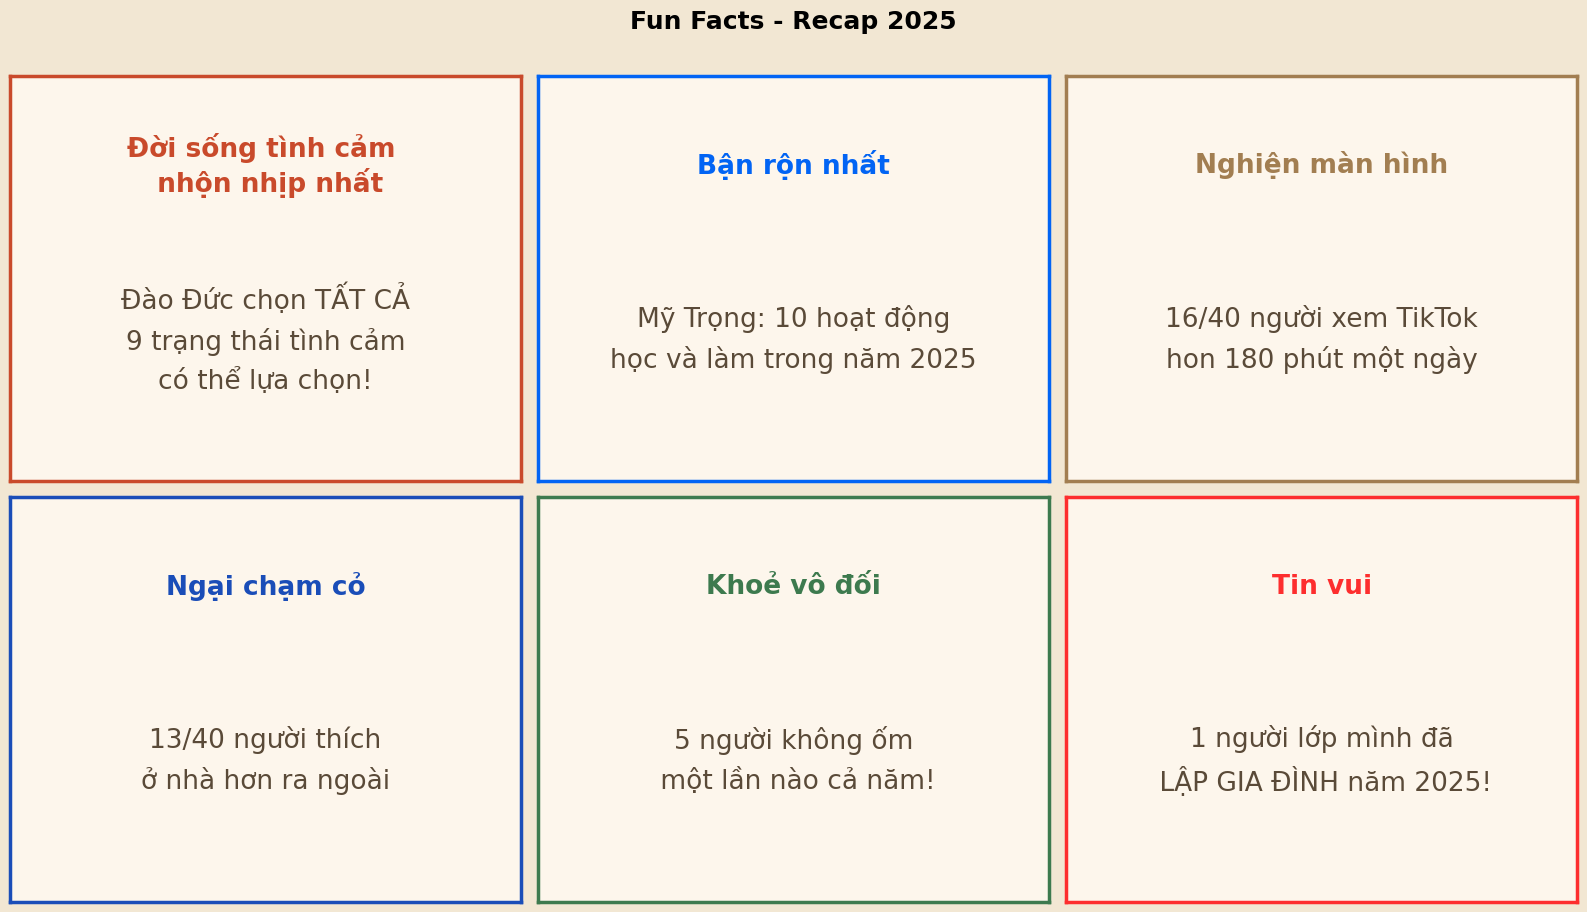

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Fun Facts - Recap 2025', fontsize=18, fontweight='bold',
             color=COLORS['text'], y=1.01)

facts = [
    ('Đời sống tình cảm \n nhộn nhịp nhất', 'Đào Đức chọn TẤT CẢ\n9 trạng thái tình cảm\ncó thể lựa chọn!',     COLORS['a3']),
    ('Bận rộn nhất',    'Mỹ Trọng: 10 hoạt động\nhọc và làm trong năm 2025',                 COLORS['a1']),
    ('Nghiện màn hình', '16/40 người xem TikTok\nhon 180 phút một ngày',                   COLORS['a2']),
    ('Ngại chạm cỏ',  '13/40 người thích\nở nhà hơn ra ngoài',                            COLORS['a4']),
    ('Khoẻ vô đối',   '5 người không ốm\n một lần nào cả năm!',                            COLORS['a5']),
    ('Tin vui',         '1 người lớp mình đã\n LẬP GIA ĐÌNH năm 2025!',                      "#fd2e2e"),
]

for ax, (title, body, color) in zip(axes.flat, facts):
    ax.set_facecolor(COLORS['panel'])
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.78, title, ha='center', va='center',
            transform=ax.transAxes, fontsize=19, fontweight='bold', color=color)
    ax.text(0.5, 0.35, body, ha='center', va='center',
            transform=ax.transAxes, fontsize=19,
            color=COLORS['muted'], linespacing=1.6)

plt.tight_layout()
plt.savefig('chart_funfacts.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## Recap 2025 — Ket

| Chi so | So lieu |
|--------|---------|
| Thanh vien tham gia | 40 nguoi |
| Da / dang di lam, thuc tap | ~95% |
| Thieu ngu tram trong | 45% |
| Cam thay biet on | 62% |
| Dang hen ho chinh thuc | 22% |
| The duc deu hang tuan | 15 nguoi |
| Nghien TikTok >3h/ngay | 16 nguoi |
| Lap gia dinh | 1 nguoi |

> Lop minh vua khoc, vua cuoi, vua truong thanh. Do chinh la 2025.

*Made with Python, pandas & Matplotlib*

In [50]:
from IPython.display import display, HTML

def who_ticked(col, title):
    rows = []
    all_options = sorted(set(
        item.strip()
        for val in df[col].dropna()
        for item in str(val).split(';')
        if item.strip()
    ))
    
    # Tính độ dài tên dài nhất để căn đều
    all_names = df['Tên của cậu là gì?'].dropna().tolist()
    max_len = 12
    
    for option in all_options:
        names = df.loc[
            df[col].apply(lambda x: option in str(x).split(';') if pd.notna(x) else False),
            'Tên của cậu là gì?'
        ].tolist()
        
        # Pad từng tên về cùng độ rộng bằng &nbsp;
        padded = []
        for name in names:
            spaces = '&nbsp;' * (max_len - len(name) + 2)
            padded.append(f"<span style='display:inline-block; min-width:{max_len}ch'>{name}</span>")
        
        names_str = '<span style="color:#d4c4aa; margin:0 4px">|</span>'.join(padded)
        count = len(names)
        
        rows.append(f"""
        <tr>
            <td style='padding:8px 14px; font-weight:600; color:#0264f4; width:35%;
                       border-bottom:1px solid #e0d0b8'>{option}</td>
            <td style='padding:8px 14px; text-align:center; font-weight:700;
                       color:#a27e51; width:8%; border-bottom:1px solid #e0d0b8'>{count}</td>
            <td style='padding:8px 14px; color:#000; width:57%; font-family:monospace;
                       border-bottom:1px solid #e0d0b8; line-height:2'>{names_str}</td>
        </tr>""")
    
    html = f"""
    <div style='margin:24px 0; font-family:sans-serif'>
        <h3 style='background:#0264f4; color:#fff; padding:12px 18px;
                   border-radius:8px 8px 0 0; margin:0'>{title}</h3>
        <table style='width:100%; border-collapse:collapse;
                      background:#fdf6ec; border-radius:0 0 8px 8px;
                      overflow:hidden; box-shadow:0 2px 8px rgba(0,0,0,0.08)'>
            <thead>
                <tr style='background:#f2e7d3'>
                    <th style='padding:8px 14px; text-align:left; color:#5a4a38'>Lựa chọn</th>
                    <th style='padding:8px 14px; color:#5a4a38'>Số người</th>
                    <th style='padding:8px 14px; text-align:left; color:#5a4a38'>Tên</th>
                </tr>
            </thead>
            <tbody>{''.join(rows)}</tbody>
        </table>
    </div>"""
    display(HTML(html))

who_ticked(COL_WORK,   '💼 Công việc & Học hành')
who_ticked(COL_HEALTH, '💊 Sức khoẻ')
who_ticked(COL_MENTAL, '🧠 Tinh thần')
who_ticked(COL_HABITS, '📱 Thói quen')
who_ticked(COL_LOVE,   '💕 Đời sống tình cảm')

Lựa chọn,Số người,Tên
Bị bắt phao,3,Thanh Hà |Hehehe đố bit ai |Hoàng Anh
Bị trượt ít nhất một môn,7,Đức Bách |Văn Lâm |Trung Nguyên |Đức Anh |Mỹ Trọng |Minh Trí |Xuân Bách
Cúp học,18,Vân Anh |Đức Bách |Ngọc Phương |Khánh Linh |Tuấn Đạt |Thanh Hà |Trung Nguyên |Đức Anh |Mỹ Trọng |Ngân Giang |Thuỳ Linh |Minh Trí |Xuân Bách |Hằng Hoa |Thu Hằng |Đình Khánh |Hehehe đố bit ai |Hoàng Anh
Gia nhập thị trường lao động,15,Hồng Huệ |Chu Ánh |Ngọc Phương |Bảo Khánh |Thanh Bình |Trần Hưởng |Khánh Linh |Thanh Hà |Thái Lê |Mỹ Trọng |Thanh Thanh |Lan Anh |Uyên Nhi |Ngọc Nga |Hoàng Quân
Học thêm 1 kỹ năng/ngôn ngữ mới,16,Hồng Huệ |Chu Ánh |Ngọc Phương |Thanh Bình |Hà Nhi |Khánh Linh |Văn Lâm |Tuấn Đạt |Thanh Hà |Trung Nguyên |Đức Anh |Mỹ Trọng |Minh Trí |Uyên Như |Lan Anh |Thu Hằng
Khởi nghiệp,4,Trung Nguyên |Thái Lê |Đức Anh |Mỹ Trọng
Làm cán sự lớp,10,Vân Anh |Chu Ánh |Ngọc Phương |Bảo Khánh |Văn Lâm |Thanh Hà |Đức Anh |Mỹ Trọng |Minh Trí |Thu Hằng
Nhảy việc,4,Ngọc Phương |Khánh Linh |Thanh Hà |Ngân Giang
Tham gia 1 cuộc thi,13,Nguyễn Hải |Ngọc Ngoan |Chu Ánh |Ngọc Phương |Bảo Khánh |Thanh Bình |Trần Hưởng |Thành Đạo |Tuấn Đạt |Trung Nguyên |Mỹ Trọng |Ngân Giang |Minh Trí
Đi du học,3,Chu Ánh |Trung Nguyên |Thu Hằng


Lựa chọn,Số người,Tên
Giảm cân,12,Ngọc Ngoan |Chu Ánh |Trần Hưởng |Thành Đạo |Khánh Linh |Tuấn Đạt |Thanh Hà |Trung Nguyên |Ngọc Mai |Lan Anh |Đình Khánh |Hoàng Anh
Hay ốm vặt,8,Vân Anh |Hồng Huệ |Thu Hà |Hoài Thu |Thanh Hà |Đức Anh |Thu Hằng |Hehehe đố bit ai
Không ốm một lần nào,5,Bảo Khánh |Văn Lâm |Trung Nguyên |Đình Khánh |Hoàng Anh
Thiếu ngủ trầm trọng,18,Vân Anh |Ngọc Ngoan |Đức Bách |Thu Hà |Trần Hưởng |Thành Đạo |Tuấn Đạt |Thanh Hà |Thái Lê |Ngân Giang |Ngọc Mai |Minh Trí |Xuân Bách |Đào Đức |Thu Hằng |Đình Khánh |Hehehe đố bit ai |Ngọc Nga
Thoát vị đĩa đệm,10,Nguyễn Hải |Đức Bách |Ngọc Phương |Tuấn Đạt |Ngọc Mai |Thanh Thanh |Xuân Bách |Thu Hằng |Đình Khánh |Hehehe đố bit ai
Tăng cân,18,Hồng Huệ |Chu Ánh |Ngọc Phương |Bảo Khánh |Thu Hà |Thành Đạo |Khánh Linh |Hoài Thu |Tuấn Đạt |Thanh Hà |Trung Nguyên |Đức Anh |Mỹ Trọng |Ngọc Mai |Xuân Bách |Hằng Hoa |Thu Hằng |Ngọc Nga
Tăng độ cận,12,Hồng Huệ |Thanh Bình |Hà Nhi |Tuấn Đạt |Thanh Hà |Đức Anh |Ngân Giang |Thuỳ Linh |Ngọc Mai |Uyên Như |Hehehe đố bit ai |Uyên Nhi
Vào viện ít nhất một lần,8,Vân Anh |Chu Ánh |Ngọc Phương |Hà Nhi |Tuấn Đạt |Thanh Hà |Đức Anh |Thu Hằng
Ăn uống healthy,9,Hồng Huệ |Ngọc Phương |Tuấn Đạt |Thanh Hà |Thái Lê |Đức Anh |Minh Trí |Lan Anh |Hoàng Quân
Đã không ngủ quá 24h liên tiếp,13,Ngọc Ngoan |Thanh Bình |Trần Hưởng |Thành Đạo |Hoài Thu |Văn Lâm |Tuấn Đạt |Trung Nguyên |Ngân Giang |Ngọc Mai |Minh Trí |Thu Hằng |Ngọc Nga


Lựa chọn,Số người,Tên
Biết cách tha thứ,13,Vân Anh |Ngọc Ngoan |Chu Ánh |Bảo Khánh |Trần Hưởng |Khánh Linh |Tuấn Đạt |Trung Nguyên |Thái Lê |Mỹ Trọng |Ngọc Mai |Lan Anh |Thu Hằng
Biết ơn rất nhiều,25,Nguyễn Hải |Vân Anh |Hồng Huệ |Ngọc Ngoan |Chu Ánh |Ngọc Phương |Bảo Khánh |Thu Hà |Thanh Bình |Hà Nhi |Trần Hưởng |Thành Đạo |Khánh Linh |Tuấn Đạt |Thanh Hà |Trung Nguyên |Thái Lê |Mỹ Trọng |Thuỳ Linh |Ngọc Mai |Lan Anh |Thu Hằng |Đình Khánh |Uyên Nhi |Hoàng Quân
Có nhiều điều thất vọng,11,Hồng Huệ |Ngọc Ngoan |Ngọc Phương |Bảo Khánh |Khánh Linh |Thanh Hà |Đức Anh |Ngọc Mai |Minh Trí |Uyên Như |Lan Anh
Có nhiều điều tự hào,14,Hồng Huệ |Ngọc Ngoan |Ngọc Phương |Bảo Khánh |Thanh Bình |Hà Nhi |Thành Đạo |Khánh Linh |Thanh Hà |Đức Anh |Ngân Giang |Minh Trí |Lan Anh |Uyên Nhi
Có những lúc stress phát điên,22,Vân Anh |Hồng Huệ |Ngọc Ngoan |Đức Bách |Chu Ánh |Ngọc Phương |Bảo Khánh |Thu Hà |Thanh Bình |Thành Đạo |Khánh Linh |Hoài Thu |Tuấn Đạt |Thanh Hà |Đức Anh |Mỹ Trọng |Minh Trí |Thanh Thanh |Lan Anh |Đào Đức |Thu Hằng |Ngọc Nga
Cười ặc ặc,19,Nguyễn Hải |Ngọc Ngoan |Ngọc Phương |Bảo Khánh |Thu Hà |Thành Đạo |Khánh Linh |Hoài Thu |Tuấn Đạt |Thanh Hà |Trung Nguyên |Đức Anh |Mỹ Trọng |Ngọc Mai |Lan Anh |Xuân Bách |Hằng Hoa |Hehehe đố bit ai |Ngọc Nga
"Day dứt, nuối tiếc vì điều gì đó",10,Vân Anh |Ngọc Phương |Bảo Khánh |Tuấn Đạt |Thanh Hà |Đức Anh |Ngân Giang |Minh Trí |Thu Hằng |Uyên Nhi
Khóc tu tu,11,Ngọc Ngoan |Chu Ánh |Ngọc Phương |Khánh Linh |Hoài Thu |Tuấn Đạt |Thanh Hà |Minh Trí |Lan Anh |Thu Hằng |Hehehe đố bit ai
Lo lắng cho tương lai,22,Vân Anh |Hồng Huệ |Ngọc Ngoan |Đức Bách |Chu Ánh |Ngọc Phương |Bảo Khánh |Thu Hà |Thành Đạo |Khánh Linh |Hoài Thu |Văn Lâm |Tuấn Đạt |Trung Nguyên |Thái Lê |Đức Anh |Ngọc Mai |Minh Trí |Xuân Bách |Đào Đức |Ngọc Nga |Hoàng Anh
Một năm chill guy,6,Nguyễn Hải |Thanh Bình |Tuấn Đạt |Trung Nguyên |Ngọc Mai |Xuân Bách


Lựa chọn,Số người,Tên
Biết nói “không” nhiều hơn,18,Nguyễn Hải |Ngọc Ngoan |Chu Ánh |Ngọc Phương |Bảo Khánh |Thanh Bình |Hà Nhi |Khánh Linh |Thanh Hà |Trung Nguyên |Thái Lê |Đức Anh |Mỹ Trọng |Minh Trí |Uyên Như |Lan Anh |Thu Hằng |Uyên Nhi
Chăm chỉ về quê ( 2 tuần 1 lần hoặc là nhiều hơn),15,Hồng Huệ |Đức Bách |Ngọc Phương |Hà Nhi |Thành Đạo |Khánh Linh |Tuấn Đạt |Trung Nguyên |Ngân Giang |Ngọc Mai |Minh Trí |Lan Anh |Xuân Bách |Ngọc Nga |Hoàng Quân
Chọn chất lượng hơn số lượng trong các mối quan hệ,15,Vân Anh |Hồng Huệ |Ngọc Ngoan |Ngọc Phương |Bảo Khánh |Thanh Bình |Trần Hưởng |Thái Lê |Đức Anh |Mỹ Trọng |Ngọc Mai |Minh Trí |Lan Anh |Đào Đức |Thu Hằng
Dần ít nói hơn trước,9,Đức Bách |Ngọc Phương |Thu Hà |Thanh Hà |Thái Lê |Đức Anh |Mỹ Trọng |Minh Trí |Thu Hằng
Hay bỏ bữa (đừng bỏ bữa nữa nha cậu ơi),8,Ngọc Ngoan |Chu Ánh |Thanh Bình |Hà Nhi |Trần Hưởng |Thành Đạo |Thanh Hà |Ngân Giang
Không còn nhiều năng lượng như hồi tuổi teen (già rồi),12,Nguyễn Hải |Vân Anh |Ngọc Ngoan |Ngọc Phương |Hoài Thu |Thanh Hà |Đức Anh |Mỹ Trọng |Ngọc Mai |Minh Trí |Thu Hằng |Đình Khánh
Thích ở nhà hơn là ra ngoài đông người,14,Nguyễn Hải |Vân Anh |Ngọc Phương |Bảo Khánh |Thu Hà |Hà Nhi |Thanh Hà |Thái Lê |Đức Anh |Ngọc Mai |Minh Trí |Xuân Bách |Hằng Hoa |Uyên Nhi
"Thể dục hằng tuần (chạy bộ, cầu lông, bóng đá, đi gym,...vận động là được)",14,Nguyễn Hải |Ngọc Ngoan |Chu Ánh |Ngọc Phương |Bảo Khánh |Thành Đạo |Văn Lâm |Trung Nguyên |Thái Lê |Ngọc Mai |Minh Trí |Lan Anh |Xuân Bách |Hoàng Anh
"Thức vào giữa tuần, ngủ bù cuối tuần",7,Vân Anh |Ngọc Ngoan |Bảo Khánh |Thanh Bình |Đức Anh |Ngân Giang |Ngọc Nga
Toàn đi ăn ngoài,6,Bảo Khánh |Thanh Bình |Thành Đạo |Văn Lâm |Thanh Hà |Ngọc Nga


Lựa chọn,Số người,Tên
Chia tay (kết thúc một mối quan hệ trong năm qua),3,Thanh Hà |Thái Lê |Đào Đức
Có cảm xúc với một người mới,6,Hà Nhi |Thành Đạo |Thái Lê |Đào Đức |Hehehe đố bit ai |Uyên Nhi
Có mối quan hệ mập mờ (khó gọi tên nhưng vẫn tồn tại),7,Vân Anh |Chu Ánh |Thanh Bình |Thái Lê |Ngọc Mai |Thanh Thanh |Đào Đức
Hết thích 1 người mình từng thích (un-crush),6,Ngọc Ngoan |Hà Nhi |Thành Đạo |Thanh Hà |Thái Lê |Đào Đức
Lập gia đình (chính thức bước sang một chương mới),1,Đào Đức
Yêu đơn phương (yêu trong im lặng là chính),1,Đào Đức
Đang hẹn hò (có danh phận rõ ràng),10,Nguyễn Hải |Đức Bách |Bảo Khánh |Thu Hà |Hoài Thu |Trung Nguyên |Mỹ Trọng |Ngân Giang |Uyên Như |Đào Đức
Đi date một người,3,Thuỳ Linh |Đào Đức |Hằng Hoa
Độc thân hoàn toàn (chưa yêu đương với ai),17,Hồng Huệ |Ngọc Ngoan |Chu Ánh |Ngọc Phương |Trần Hưởng |Thành Đạo |Khánh Linh |Tuấn Đạt |Đức Anh |Ngọc Mai |Xuân Bách |Đào Đức |Thu Hằng |Đình Khánh |Uyên Nhi |Ngọc Nga |Hoàng Anh


In [60]:
from IPython.display import display, HTML

def who_ticked_html(col, title):
    """Tạo HTML cho một bảng thống kê"""
    rows = []
    all_options = sorted(set(
        item.strip()
        for val in df[col].dropna()
        for item in str(val).split(';')
        if item.strip()
    ))
    
    all_names = df['Tên của cậu là gì?'].dropna().tolist()
    max_len = 12
    
    for idx, option in enumerate(all_options):
        names = df.loc[
            df[col].apply(lambda x: option in str(x).split(';') if pd.notna(x) else False),
            'Tên của cậu là gì?'
        ].tolist()
        
        padded = []
        for name in names:
            padded.append(f"<span style='display:inline-block; min-width:120px'>{name}</span>")
        
        names_str = '<span style="color:#d4c4aa; margin:0 4px">|</span>'.join(padded)
        count = len(names)
        
        # Màu so le: chẵn = #fdf6ec (sáng), lẻ = #f8f0e0 (nhạt hơn chút)
        bg_color = '#fdf6ec' if idx % 2 == 0 else '#f8f0e0'
        
        rows.append(f"""
        <tr style='background:{bg_color}'>
            <td style='padding:8px 14px; font-weight:600; color:#0264f4; width:15%;
                       border-bottom:1px solid #e0d0b8'>{option}</td>
            <td style='padding:8px 14px; text-align:center; font-weight:700;
                       color:#a27e51; width:8%; border-bottom:1px solid #e0d0b8'>{count}</td>
            <td style='padding:8px 14px; color:#000; width:77%;
                       border-bottom:1px solid #e0d0b8; line-height:2'>{names_str}</td>
        </tr>""")
    
    return f"""
    <div style='margin:24px 0; font-family:sans-serif; page-break-inside:avoid'>
        <h3 style='background:#0264f4; color:#fff; padding:12px 18px;
                   border-radius:8px 8px 0 0; margin:0'>{title}</h3>
        <table style='width:100%; border-collapse:collapse;
                      border-radius:0 0 8px 8px;
                      overflow:hidden; box-shadow:0 2px 8px rgba(0,0,0,0.08)'>
            <thead>
                <tr style='background:#f2e7d3'>
                    <th style='padding:8px 14px; text-align:left; color:#5a4a38'>Lựa chọn</th>
                    <th style='padding:8px 14px; color:#5a4a38'>Số người</th>
                    <th style='padding:8px 14px; text-align:left; color:#5a4a38'>Tên</th>
                </tr>
            </thead>
            <tbody>{''.join(rows)}</tbody>
        </table>
    </div>"""

# Gom tất cả bảng vào một HTML
full_html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Recap 2025 - Thống kê chi tiết</title>
    <style>
        body {{ 
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: #f2e7d3;
            padding: 40px;
            margin: 0;
        }}
        h1 {{
            text-align: center;
            color: #0264f4;
            margin-bottom: 40px;
            font-size: 36px;
        }}
        @media print {{
            body {{ padding: 20px; }}
        }}
    </style>
</head>
<body>
    <h1>🎓 Recap 2025 — Thống kê chi tiết</h1>
    {who_ticked_html(COL_WORK,   '💼 Công việc & Học hành')}
    {who_ticked_html(COL_HEALTH, '💊 Sức khoẻ')}
    {who_ticked_html(COL_MENTAL, '🧠 Tinh thần')}
    {who_ticked_html(COL_HABITS, '📱 Thói quen')}
    {who_ticked_html(COL_LOVE,   '💕 Đời sống tình cảm')}
</body>
</html>
"""

# Lưu HTML
with open('main.html', 'w', encoding='utf-8') as f:
    f.write(full_html)

print("✅ Đã tạo file main.html")
print("📄 Mở file bằng Chrome/Firefox → Ctrl+P → Save as PDF")

✅ Đã tạo file main.html
📄 Mở file bằng Chrome/Firefox → Ctrl+P → Save as PDF
